# Лабораторна робота №5. Алгоритми пошуку 

##### AUTHOR

© Kremliakov Hlib

### Мета

Засвоїти варіанти реалізації алгоритмів пошуку засобами Python і методи оцінювання їх складності. 

## Хід роботи

### Завдання

Реалізувати контрольні приклади.

Оцінити асимптотичну складність алгоритму лінійного пошуку в О-нотації.

− оцінити асимптотичну складність алгоритму бінарного пошуку в  
О-нотації.

− написати функцію, яка б могла повертати датафрейм з таким складом 
полів: («n», «time»), де n – розмір масиву для функції linear_searh(); 

− написати функцію, яка б могла повертати датафрейм з таким складом 
полів: («n», «time»), де n – розмір масиву для функції bin_searh(); 

− за результатами попередніх завдань побудувати графіки залежності часу 
виконання процедури пошуку від розміру масиву. 

− оцінити, який з двох алгоритмів є ефективнішим і в якому діапазоні 
розміру задачі.

## Виконання

In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt

### Реалізація лінійного пошуку

In [4]:
def linear_search(a_list, x):
    i = 0
    length = len(a_list)

    while i < length and x != a_list[i]:
        i += 1

    if i < length:
        return i
    else:
        return -1

### Перевірка лінійного пошуку

In [5]:
a = [32, 1, 3, 4, 2, 1]

search_item = int(input("Введіть число: "))

result = linear_search(a, search_item)

print("Результат:", result)

Введіть число:  1


Результат: 1


### Реалізація бінарного пошуку

In [6]:
def bin_search(a_list, x, left, right):

    if left > right or len(a_list) == 0:
        return -1

    middle = (left + right) // 2

    if a_list[middle] == x:
        return middle

    elif a_list[middle] < x:
        return bin_search(a_list, x, middle + 1, right)

    else:
        return bin_search(a_list, x, left, middle - 1)

### Перевірка бінарного пошуку

In [7]:
a = list(range(1, 21))

search_item = int(input("Введіть число: "))

result = bin_search(a, search_item, 0, len(a) - 1)

print("Результат:", result)

Введіть число:  6


Результат: 5


### Теоретична частина — складність алгоритмів

#### Асимптотична складність

##### Лінійний пошук
Складність алгоритму лінійного пошуку становить O(n), оскільки в найгіршому випадку необхідно перевірити всі елементи масиву.

##### Бінарний пошук
Складність алгоритму бінарного пошуку становить O(log n), оскільки на кожному кроці область пошуку ділиться навпіл.

### Функція вимірювання часу linear_search

In [10]:
def linear_search_test():

    sizes = []
    times = []

    for n in range(1000, 10001, 1000):

        a = list(range(n))

        start = time.perf_counter()

        linear_search(a, n - 1)

        end = time.perf_counter()

        sizes.append(n)
        times.append(end - start)

    df = pd.DataFrame({
        "n": sizes,
        "time": times
    })

    return df

#### Запуск тесту linear_search

In [11]:
linear_df = linear_search_test()

linear_df

,n,time
0,1000,0.000096
1,2000,0.000189
2,3000,0.000284
3,4000,0.000379
4,5000,0.000473
5,6000,0.000630
6,7000,0.000452
7,8000,0.000507
8,9000,0.000570
9,10000,0.000646


### Функція вимірювання часу bin_search

In [12]:
def bin_search_test():

    sizes = []
    times = []

    for n in range(1000, 10001, 1000):

        a = list(range(n))

        start = time.perf_counter()

        bin_search(a, n - 1, 0, len(a) - 1)

        end = time.perf_counter()

        sizes.append(n)
        times.append(end - start)

    df = pd.DataFrame({
        "n": sizes,
        "time": times
    })

    return df

#### Запуск тесту bin_search

In [14]:
bin_df = bin_search_test()

bin_df

,n,time
0,1000,0.000008
1,2000,0.000003
2,3000,0.000004
3,4000,0.000004
4,5000,0.000004
5,6000,0.000004
6,7000,0.000004
7,8000,0.000005
8,9000,0.000005
9,10000,0.000004


### Побудова графіка linear_search

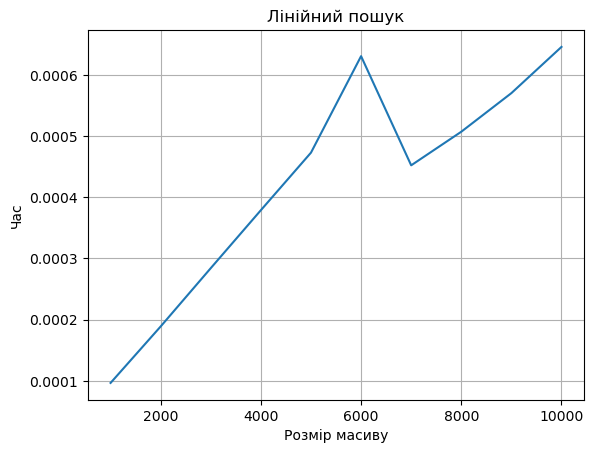

In [15]:
plt.plot(linear_df["n"], linear_df["time"])

plt.title("Лінійний пошук")
plt.xlabel("Розмір масиву")
plt.ylabel("Час")

plt.grid()

plt.show()

### Побудова графіка bin_search

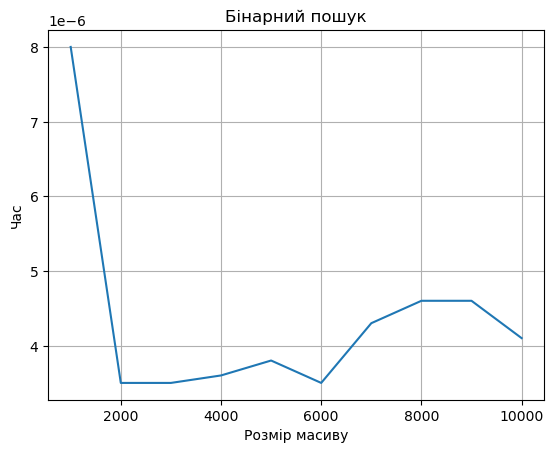

In [16]:
plt.plot(bin_df["n"], bin_df["time"])

plt.title("Бінарний пошук")
plt.xlabel("Розмір масиву")
plt.ylabel("Час")

plt.grid()

plt.show()

### Загальний графік

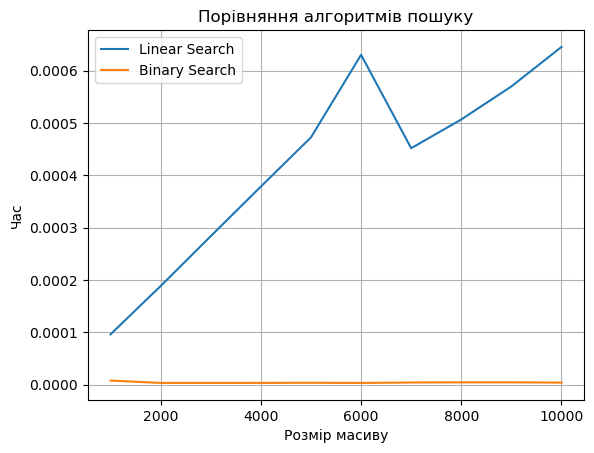

In [17]:
plt.plot(linear_df["n"], linear_df["time"], label="Linear Search")

plt.plot(bin_df["n"], bin_df["time"], label="Binary Search")

plt.xlabel("Розмір масиву")
plt.ylabel("Час")

plt.title("Порівняння алгоритмів пошуку")

plt.legend()

plt.grid()

plt.show()

## Висновок

У ході лабораторної роботи було реалізовано алгоритми лінійного та бінарного пошуку мовою Python. Було проведено аналіз часу виконання алгоритмів для різних розмірів масивів. Експериментально підтверджено, що бінарний пошук працює значно швидше для великих масивів, оскільки має складність O(log n), тоді як лінійний пошук має складність O(n). Бінарний пошук є ефективнішим для відсортованих масивів.

## Контрольні питання

### 1. Сформулювати задачу пошуку.

Задача пошуку полягає у знаходженні певного елемента в наборі даних або визначенні факту його відсутності. Результатом пошуку може бути індекс елемента, сам елемент або повідомлення про його відсутність.



### 2. Які критерії можна використовувати для оцінювання ефективності алгоритмів пошуку?

Для оцінювання ефективності алгоритмів пошуку використовують такі критерії:
- час виконання алгоритму;
- асимптотична складність;
- обсяг використовуваної пам’яті;
- кількість операцій порівняння;
- швидкість роботи на великих обсягах даних.



### 3. Що таке лінійний пошук і яка його асимптотична складність?

Лінійний пошук — це алгоритм пошуку, при якому елементи масиву переглядаються послідовно один за одним, починаючи з першого елемента.

Асимптотична складність лінійного пошуку: 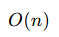

У найгіршому випадку алгоритм перевіряє всі елементи масиву.



### 4. Що таке бінарний (двійковий) пошук і в чому полягає його головний принцип роботи?

Бінарний пошук — це алгоритм пошуку у відсортованому масиві, який на кожному кроці ділить область пошуку навпіл.

Головний принцип роботи полягає у порівнянні шуканого елемента із середнім елементом масиву. Після цього пошук продовжується лише в одній половині масиву.

Асимптотична складність бінарного пошуку: 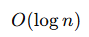



### 5. Які переваги і недоліки використання бінарного пошуку порівняно з лінійним?

Переваги бінарного пошуку:
- висока швидкість роботи;
- ефективність для великих масивів;
- менша кількість порівнянь.

Недоліки:
- працює лише з відсортованими даними;
- складніший у реалізації порівняно з лінійним пошуком.

Переваги лінійного пошуку:
- простота реалізації;
- може працювати з невідсортованими масивами.

Недоліки:
- повільна робота на великих масивах;
- велика кількість перевірок.



### 6. Які ще алгоритми пошуку існують, окрім лінійного і бінарного?

Окрім лінійного та бінарного пошуку існують:
- інтерполяційний пошук;
- пошук стрибками;
- експоненціальний пошук;
- пошук у хеш-таблицях;
- пошук у бінарних деревах;
- пошук у графах;
- пошук у рядках.